# Visual Understanding with TextVQA: Combined analysis
## AI in Medicine - Spring 2026 Final Project
**Model:** Qwen2.5-VL-3B-Instruct & LLaVA-Phi-3-mini  
**Approach:** Prompt Engineering  
**Dataset:** TextVQA  
**Notebook content**: This notebook contains code that runs analysis for the two models combined.

In [46]:
%cd drive/MyDrive/School/SP26/SHBT261/final_project

[Errno 2] No such file or directory: 'drive/MyDrive/School/SP26/SHBT261/final_project'
/content/drive/MyDrive/School/SP26/SHBT261/final_project


In [47]:
import os
import ast
import math
import textwrap
import re
import json
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
import seaborn as sns

COMBINED_OUTPUT_DIR = "combined_report_outputs"
os.makedirs(COMBINED_OUTPUT_DIR, exist_ok=True)

MODEL_CONFIGS = {
    "qwen": {
        "display_name": "Qwen2.5-VL-3B",
        "saved_results_dir": "qwen/saved_results",
    },
    "llava": {
        "display_name": "LLaVA-Phi-3-mini",
        "saved_results_dir": "llava/saved_results",
    },
}

STRATEGY_ORDER = ["zeroshot_raw", "baseline", "task_description", "few_shot"]

## Helper functions

In [48]:
def normalize_answer_text(text):
    text = "" if text is None else str(text)
    text = text.lower().strip()
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def tokenize_answer_text(text):
    text = normalize_answer_text(text)
    if text == "":
        return []
    return text.split()


def exact_any_match(prediction, answers):
    pred = normalize_answer_text(prediction)
    refs = [normalize_answer_text(a) for a in answers]
    return int(pred in refs)


def best_token_overlap_metrics(prediction, answers):
    pred_tokens = tokenize_answer_text(prediction)
    if len(pred_tokens) == 0:
        return 0.0, 0.0, 0.0

    best_precision = 0.0
    best_recall = 0.0
    best_f1 = 0.0

    pred_counter = Counter(pred_tokens)

    for answer in answers:
        ref_tokens = tokenize_answer_text(answer)
        if len(ref_tokens) == 0:
            continue

        ref_counter = Counter(ref_tokens)
        overlap = sum((pred_counter & ref_counter).values())

        precision = overlap / max(len(pred_tokens), 1)
        recall = overlap / max(len(ref_tokens), 1)

        if precision + recall == 0:
            f1 = 0.0
        else:
            f1 = 2 * precision * recall / (precision + recall)

        if f1 > best_f1:
            best_precision = precision
            best_recall = recall
            best_f1 = f1

    return best_precision, best_recall, best_f1


def question_type(question):
    q = normalize_answer_text(question)

    if q.startswith("how many") or q.startswith("what number") or "number" in q or "amount" in q:
        return "number_count"

    if "color" in q or "colour" in q:
        return "color"

    if "price" in q or "cost" in q or "currency" in q or "dollar" in q or "cents" in q:
        return "price_currency"

    if q.startswith("where") or "location" in q or "place" in q:
        return "location"

    if q.startswith("when") or "date" in q or "time" in q or "year" in q:
        return "date_time"

    if q.startswith("who") or "person" in q or "name of the person" in q:
        return "person"

    if q.startswith("is ") or q.startswith("are ") or q.startswith("does ") or q.startswith("do "):
        return "yes_no"

    if "brand" in q or "company" in q or "logo" in q:
        return "brand_logo"

    if "say" in q or "written" in q or "read" in q or "text" in q or "word" in q or "letter" in q:
        return "scene_text"

    if q.startswith("what"):
        return "general_what"

    return "other"


def answer_type(answers):
    normalized_answers = [normalize_answer_text(a) for a in answers]
    normalized_answers = [a for a in normalized_answers if a != ""]

    if len(normalized_answers) == 0:
        return "empty_reference"

    if all(a in ["yes", "no"] for a in normalized_answers):
        return "yes_no"

    if any(re.fullmatch(r"[0-9]+(\.[0-9]+)?", a) for a in normalized_answers):
        return "numeric"

    if any(re.search(r"[0-9]", a) and re.search(r"[a-z]", a) for a in normalized_answers):
        return "alphanumeric"

    token_lengths = [len(a.split()) for a in normalized_answers]

    if np.median(token_lengths) <= 1:
        return "single_word"

    return "multi_word"


def categorize_error(prediction, answers):
    pred = normalize_answer_text(prediction)
    refs = [normalize_answer_text(a) for a in answers]
    refs = [a for a in refs if a != ""]

    if pred == "":
        return "empty_output"

    if pred in refs:
        return "metric_mismatch"

    pred_tokens = set(tokenize_answer_text(prediction))
    ref_token_sets = [set(tokenize_answer_text(a)) for a in refs]

    for ref_tokens in ref_token_sets:
        if len(ref_tokens) > 0:
            overlap = len(pred_tokens & ref_tokens) / len(ref_tokens)
            if overlap >= 0.5:
                return "partial_ocr_or_partial_answer"

    pred_chars = set(pred.replace(" ", ""))

    for ref in refs:
        ref_chars = set(ref.replace(" ", ""))
        if len(ref_chars) > 0:
            char_overlap = len(pred_chars & ref_chars) / len(ref_chars)
            if char_overlap >= 0.5:
                return "ocr_misread"

    if any(re.search(r"[0-9]", ref) for ref in refs) and re.search(r"[0-9]", pred):
        return "number_mismatch"

    if len(pred.split()) >= 8:
        return "too_verbose_or_descriptive"

    return "reasoning_or_grounding_failure"


def load_json_file(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_model_strategy_results(saved_results_dir, strategy_name):
    final_path = os.path.join(saved_results_dir, f"{strategy_name}_final.json")
    judge_path = os.path.join(saved_results_dir, f"{strategy_name}_judge.json")

    if not os.path.exists(final_path):
        return None

    data = load_json_file(final_path)

    if os.path.exists(judge_path):
        judge_data = load_json_file(judge_path)
        judge_by_idx = {}

        for item in judge_data:
            sample_idx = item.get("sample_idx")
            if sample_idx is not None:
                judge_by_idx[sample_idx] = item

        for item in data:
            sample_idx = item.get("sample_idx")
            judge_item = judge_by_idx.get(sample_idx)

            if judge_item is not None:
                for key in ["llm_judge_similarity", "llm_judge_reason", "llm_judge_parse_error"]:
                    if key in judge_item:
                        item[key] = judge_item[key]

    return data

## Load and combine saved model outputs

In [49]:
rows = []

for model_slug, config in MODEL_CONFIGS.items():
    saved_results_dir = config["saved_results_dir"]
    display_name = config["display_name"]

    print("Loading:", display_name)
    print("Path:", saved_results_dir)

    for strategy_name in STRATEGY_ORDER:
        data = load_model_strategy_results(saved_results_dir, strategy_name)

        if data is None:
            print("Missing:", model_slug, strategy_name)
            continue

        print(strategy_name, len(data))

        for item in data:
            answers = item.get("answers", [])
            prediction = item.get("prediction", "")
            precision, recall, token_f1 = best_token_overlap_metrics(prediction, answers)

            row = {
                "model": display_name,
                "model_slug": model_slug,
                "strategy": strategy_name,
                "sample_idx": item.get("sample_idx"),
                "question": item.get("question", ""),
                "answers": answers,
                "prediction": prediction,
                "raw_prediction": item.get("raw_prediction", ""),
                "accuracy": item.get("accuracy", np.nan),
                "bleu": item.get("bleu", np.nan),
                "meteor": item.get("meteor", np.nan),
                "rouge_l": item.get("rouge_l", np.nan),
                "llm_judge_similarity": item.get("llm_judge_similarity", np.nan),
                "llm_judge_parse_error": item.get("llm_judge_parse_error", np.nan),
                "llm_judge_reason": item.get("llm_judge_reason", ""),
                "exact_any_match": exact_any_match(prediction, answers),
                "token_precision": precision,
                "token_recall": recall,
                "token_f1": token_f1,
                "question_type": question_type(item.get("question", "")),
                "answer_type": answer_type(answers),
                "is_fully_correct": int(item.get("accuracy", 0.0) >= 1.0),
                "is_partially_correct": int(0.0 < item.get("accuracy", 0.0) < 1.0),
                "is_wrong": int(item.get("accuracy", 0.0) <= 0.0),
            }

            if row["is_fully_correct"] == 1:
                row["error_type"] = "correct"
            else:
                row["error_type"] = categorize_error(prediction, answers)

            rows.append(row)

combined_df = pd.DataFrame(rows)

combined_csv = os.path.join(COMBINED_OUTPUT_DIR, "combined_per_sample_augmented.csv")
combined_df.to_csv(combined_csv, index=False)

print("Saved:", combined_csv)
display(combined_df.head())

Loading: Qwen2.5-VL-3B
Path: qwen/saved_results
zeroshot_raw 5000
baseline 5000
task_description 5000
few_shot 5000
Loading: LLaVA-Phi-3-mini
Path: llava/saved_results
zeroshot_raw 5000
baseline 5000
task_description 5000
few_shot 5000
Saved: combined_report_outputs/combined_per_sample_augmented.csv


,model,model_slug,strategy,sample_idx,question,answers,prediction,raw_prediction,accuracy,bleu,...,exact_any_match,token_precision,token_recall,token_f1,question_type,answer_type,is_fully_correct,is_partially_correct,is_wrong,error_type
0,Qwen2.5-VL-3B,qwen,zeroshot_raw,0,what is the brand of this camera?,"[nous les gosses, dakota, clos culombu, dakota...",the brand of the camera in the picture is dako...,The brand of the camera in the picture is Dako...,0.0,0.039864,...,0,0.250000,1.000000,0.400000,brand_logo,multi_word,0,0,1,partial_ocr_or_partial_answer
1,Qwen2.5-VL-3B,qwen,zeroshot_raw,1,what does the small white text spell?,"[copenhagen, copenhagen, copenhagen, copenhage...",copenhagen,COPENHAGEN,1.0,0.177828,...,1,1.000000,1.000000,1.000000,scene_text,single_word,1,0,0,correct
2,Qwen2.5-VL-3B,qwen,zeroshot_raw,2,what kind of beer is this?,"[ale, sublimely self-righteous ale, stone, ale...","the beer in the picture is ""sublimely self-rig...","The beer in the picture is ""Sublimely Self-Rig...",0.0,0.039864,...,0,0.200000,0.666667,0.307692,general_what,single_word,0,0,1,partial_ocr_or_partial_answer
3,Qwen2.5-VL-3B,qwen,zeroshot_raw,3,what brand liquor is on the right?,"[bowmore , bowmore, bowmore, bowmore, bowmore,...",the brand of liquor on the right is bowmore is...,The brand of liquor on the right is Bowmore Is...,0.0,0.030206,...,0,0.166667,1.000000,0.285714,brand_logo,single_word,0,0,1,partial_ocr_or_partial_answer
4,Qwen2.5-VL-3B,qwen,zeroshot_raw,4,how long has the drink on the right been aged?,"[10 years, 10 year, 10 years, 10 years , 10 ye...","the drink on the right, which is bowmore islay...","The drink on the right, which is Bowmore Islay...",0.0,0.021533,...,0,0.117647,1.000000,0.210526,other,numeric,0,0,1,partial_ocr_or_partial_answer


## Validation checks

In [50]:
validation_rows = []

for model_slug, model_group in combined_df.groupby("model_slug"):
    for strategy_name, strategy_group in model_group.groupby("strategy"):
        validation_rows.append({
            "Model": model_slug,
            "Strategy": strategy_name,
            "NumSamples": len(strategy_group),
            "UniqueSampleIdx": strategy_group["sample_idx"].nunique(),
            "MissingPredictionRate": strategy_group["prediction"].isna().mean(),
            "EmptyPredictionRate": (strategy_group["prediction"].fillna("").astype(str).str.strip() == "").mean(),
            "MeanAccuracy": strategy_group["accuracy"].mean(),
        })

validation_df = pd.DataFrame(validation_rows)

validation_csv = os.path.join(COMBINED_OUTPUT_DIR, "validation_checks.csv")
validation_df.to_csv(validation_csv, index=False)

print("Saved:", validation_csv)
display(validation_df)

Saved: combined_report_outputs/validation_checks.csv


,Model,Strategy,NumSamples,UniqueSampleIdx,MissingPredictionRate,EmptyPredictionRate,MeanAccuracy
0,llava,baseline,5000,5000,0.0,0.0036,0.486467
1,llava,few_shot,5000,5000,0.0,0.0002,0.377333
2,llava,task_description,5000,5000,0.0,0.0026,0.476267
3,llava,zeroshot_raw,5000,5000,0.0,0.0136,0.206333
4,qwen,baseline,5000,5000,0.0,0.0000,0.772733
5,qwen,few_shot,5000,5000,0.0,0.0000,0.760000
6,qwen,task_description,5000,5000,0.0,0.0000,0.753333
7,qwen,zeroshot_raw,5000,5000,0.0,0.0000,0.057000


## Combined strategy summary

In [51]:
summary_rows = []

for (model_slug, model_name, strategy_name), group in combined_df.groupby(["model_slug", "model", "strategy"]):
    row = {
        "Model": model_name,
        "ModelSlug": model_slug,
        "Strategy": strategy_name,
        "NumSamples": len(group),
        "Accuracy": group["accuracy"].mean(),
        "ExactAnyMatch": group["exact_any_match"].mean(),
        "BLEU": group["bleu"].mean(),
        "METEOR": group["meteor"].mean(),
        "ROUGE-L": group["rouge_l"].mean(),
        "TokenF1": group["token_f1"].mean(),
        "TokenPrecision": group["token_precision"].mean(),
        "TokenRecall": group["token_recall"].mean(),
    }

    if group["llm_judge_similarity"].notna().any():
        row["LLM-Judge"] = group["llm_judge_similarity"].mean()
        row["LLM-Judge-Scored"] = int(group["llm_judge_similarity"].notna().sum())
        row["LLM-Judge-ParseErrorRate"] = group["llm_judge_parse_error"].fillna(False).astype(bool).mean()

    summary_rows.append(row)

combined_summary_df = pd.DataFrame(summary_rows)

combined_summary_df["strategy_order"] = combined_summary_df["Strategy"].map({
    "zeroshot_raw": 0,
    "baseline": 1,
    "task_description": 2,
    "few_shot": 3,
})

combined_summary_df = combined_summary_df.sort_values(["ModelSlug", "strategy_order"]).drop(columns=["strategy_order"])

summary_csv = os.path.join(COMBINED_OUTPUT_DIR, "combined_strategy_summary.csv")
summary_tex = os.path.join(COMBINED_OUTPUT_DIR, "combined_strategy_summary.tex")

combined_summary_df.to_csv(summary_csv, index=False)
combined_summary_df.to_latex(summary_tex, index=False, float_format="%.4f")

print("Saved:", summary_csv)
print("Saved:", summary_tex)
display(combined_summary_df)


Saved: combined_report_outputs/combined_strategy_summary.csv
Saved: combined_report_outputs/combined_strategy_summary.tex


,Model,ModelSlug,Strategy,NumSamples,Accuracy,ExactAnyMatch,BLEU,METEOR,ROUGE-L,TokenF1,TokenPrecision,TokenRecall,LLM-Judge,LLM-Judge-Scored,LLM-Judge-ParseErrorRate
3,LLaVA-Phi-3-mini,llava,zeroshot_raw,5000,0.206333,0.2166,0.073723,0.267733,0.325742,0.330255,0.298792,0.516472,0.4927,5000,0.0
0,LLaVA-Phi-3-mini,llava,baseline,5000,0.486467,0.5218,0.139951,0.358144,0.582030,0.575539,0.579502,0.586624,0.5885,5000,0.0
2,LLaVA-Phi-3-mini,llava,task_description,5000,0.476267,0.5104,0.134740,0.348235,0.571601,0.564893,0.569680,0.576406,0.5850,5000,0.0
1,LLaVA-Phi-3-mini,llava,few_shot,5000,0.377333,0.4010,0.114895,0.321515,0.479372,0.477593,0.468081,0.552273,0.5568,5000,0.0
7,Qwen2.5-VL-3B,qwen,zeroshot_raw,5000,0.057000,0.0608,0.062216,0.375137,0.278124,0.311470,0.222163,0.825514,0.8333,5000,0.0
4,Qwen2.5-VL-3B,qwen,baseline,5000,0.772733,0.8136,0.225002,0.541337,0.847170,0.843168,0.844941,0.848871,0.8548,5000,0.0
6,Qwen2.5-VL-3B,qwen,task_description,5000,0.753333,0.7962,0.218284,0.537547,0.836570,0.833221,0.835281,0.840426,0.8515,5000,0.0
5,Qwen2.5-VL-3B,qwen,few_shot,5000,0.760000,0.8018,0.209521,0.520392,0.834986,0.831250,0.837913,0.832397,0.8419,5000,0.0


## Best strategy

In [52]:
best_rows = []

for model_slug, group in combined_summary_df.groupby("ModelSlug"):
    best_row = group.sort_values("Accuracy", ascending=False).iloc[0].to_dict()
    best_rows.append(best_row)

best_strategy_df = pd.DataFrame(best_rows)

best_csv = os.path.join(COMBINED_OUTPUT_DIR, "best_strategy_by_model.csv")
best_tex = os.path.join(COMBINED_OUTPUT_DIR, "best_strategy_by_model.tex")

best_strategy_df.to_csv(best_csv, index=False)
best_strategy_df.to_latex(best_tex, index=False, float_format="%.4f")

print("Saved:", best_csv)
print("Saved:", best_tex)
display(best_strategy_df)


Saved: combined_report_outputs/best_strategy_by_model.csv
Saved: combined_report_outputs/best_strategy_by_model.tex


,Model,ModelSlug,Strategy,NumSamples,Accuracy,ExactAnyMatch,BLEU,METEOR,ROUGE-L,TokenF1,TokenPrecision,TokenRecall,LLM-Judge,LLM-Judge-Scored,LLM-Judge-ParseErrorRate
0,LLaVA-Phi-3-mini,llava,baseline,5000,0.486467,0.5218,0.139951,0.358144,0.58203,0.575539,0.579502,0.586624,0.5885,5000,0.0
1,Qwen2.5-VL-3B,qwen,baseline,5000,0.772733,0.8136,0.225002,0.541337,0.84717,0.843168,0.844941,0.848871,0.8548,5000,0.0


## Improvement over raw zero-shot

In [53]:
improvement_rows = []

for model_slug, group in combined_summary_df.groupby("ModelSlug"):
    raw_group = group[group["Strategy"] == "zeroshot_raw"]

    if len(raw_group) != 1:
        continue

    raw_acc = float(raw_group["Accuracy"].iloc[0])
    raw_judge = float(raw_group["LLM-Judge"].iloc[0]) if "LLM-Judge" in raw_group.columns else np.nan

    for _, row in group.iterrows():
        output_row = {
            "Model": row["Model"],
            "ModelSlug": row["ModelSlug"],
            "Strategy": row["Strategy"],
            "Accuracy": row["Accuracy"],
            "AccuracyImprovementOverRaw": row["Accuracy"] - raw_acc,
        }

        if "LLM-Judge" in group.columns:
            output_row["LLM-Judge"] = row.get("LLM-Judge", np.nan)
            output_row["LLMJudgeImprovementOverRaw"] = row.get("LLM-Judge", np.nan) - raw_judge

        improvement_rows.append(output_row)

combined_improvement_df = pd.DataFrame(improvement_rows)

improvement_csv = os.path.join(COMBINED_OUTPUT_DIR, "combined_prompt_improvements.csv")
improvement_tex = os.path.join(COMBINED_OUTPUT_DIR, "combined_prompt_improvements.tex")

combined_improvement_df.to_csv(improvement_csv, index=False)
combined_improvement_df.to_latex(improvement_tex, index=False, float_format="%.4f")

print("Saved:", improvement_csv)
print("Saved:", improvement_tex)
display(combined_improvement_df)

Saved: combined_report_outputs/combined_prompt_improvements.csv
Saved: combined_report_outputs/combined_prompt_improvements.tex


,Model,ModelSlug,Strategy,Accuracy,AccuracyImprovementOverRaw,LLM-Judge,LLMJudgeImprovementOverRaw
0,LLaVA-Phi-3-mini,llava,zeroshot_raw,0.206333,0.000000,0.4927,0.0000
1,LLaVA-Phi-3-mini,llava,baseline,0.486467,0.280133,0.5885,0.0958
2,LLaVA-Phi-3-mini,llava,task_description,0.476267,0.269933,0.5850,0.0923
3,LLaVA-Phi-3-mini,llava,few_shot,0.377333,0.171000,0.5568,0.0641
4,Qwen2.5-VL-3B,qwen,zeroshot_raw,0.057000,0.000000,0.8333,0.0000
5,Qwen2.5-VL-3B,qwen,baseline,0.772733,0.715733,0.8548,0.0215
6,Qwen2.5-VL-3B,qwen,task_description,0.753333,0.696333,0.8515,0.0182
7,Qwen2.5-VL-3B,qwen,few_shot,0.760000,0.703000,0.8419,0.0086


## Metrics Figures

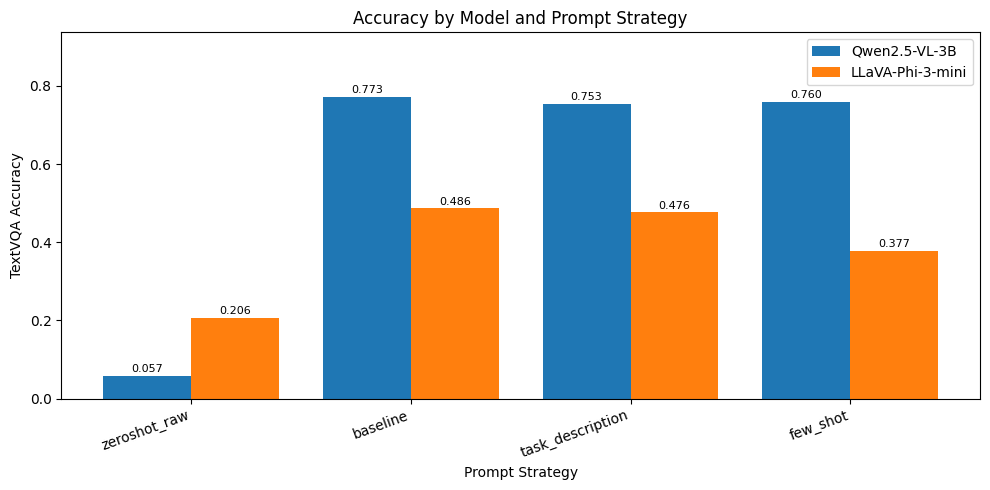

Saved: combined_report_outputs/combined_accuracy_by_strategy.png


In [54]:
# combined accuracy figure

plot_df = combined_summary_df.copy()
plot_df["Strategy"] = pd.Categorical(plot_df["Strategy"], categories=STRATEGY_ORDER, ordered=True)
plot_df = plot_df.sort_values(["Strategy", "ModelSlug"])

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(STRATEGY_ORDER))
model_slugs = list(MODEL_CONFIGS.keys())
width = 0.8 / max(len(model_slugs), 1)

for i, model_slug in enumerate(model_slugs):
    model_plot_df = plot_df[plot_df["ModelSlug"] == model_slug].set_index("Strategy")
    values = [model_plot_df.loc[s, "Accuracy"] if s in model_plot_df.index else np.nan for s in STRATEGY_ORDER]
    offsets = x - 0.4 + width / 2 + i * width
    label = MODEL_CONFIGS[model_slug]["display_name"]

    ax.bar(offsets, values, width=width, label=label)

    for xpos, value in zip(offsets, values):
        if not np.isnan(value):
            ax.text(xpos, value + 0.005, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_title("Accuracy by Model and Prompt Strategy")
ax.set_ylabel("TextVQA Accuracy")
ax.set_xlabel("Prompt Strategy")
ax.set_xticks(x)
ax.set_xticklabels(STRATEGY_ORDER, rotation=20, ha="right")
ax.set_ylim(0, max(plot_df["Accuracy"]) * 1.2 + 0.01)
ax.legend()

plt.tight_layout()

accuracy_plot_path = os.path.join(COMBINED_OUTPUT_DIR, "combined_accuracy_by_strategy.png")
plt.savefig(accuracy_plot_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", accuracy_plot_path)

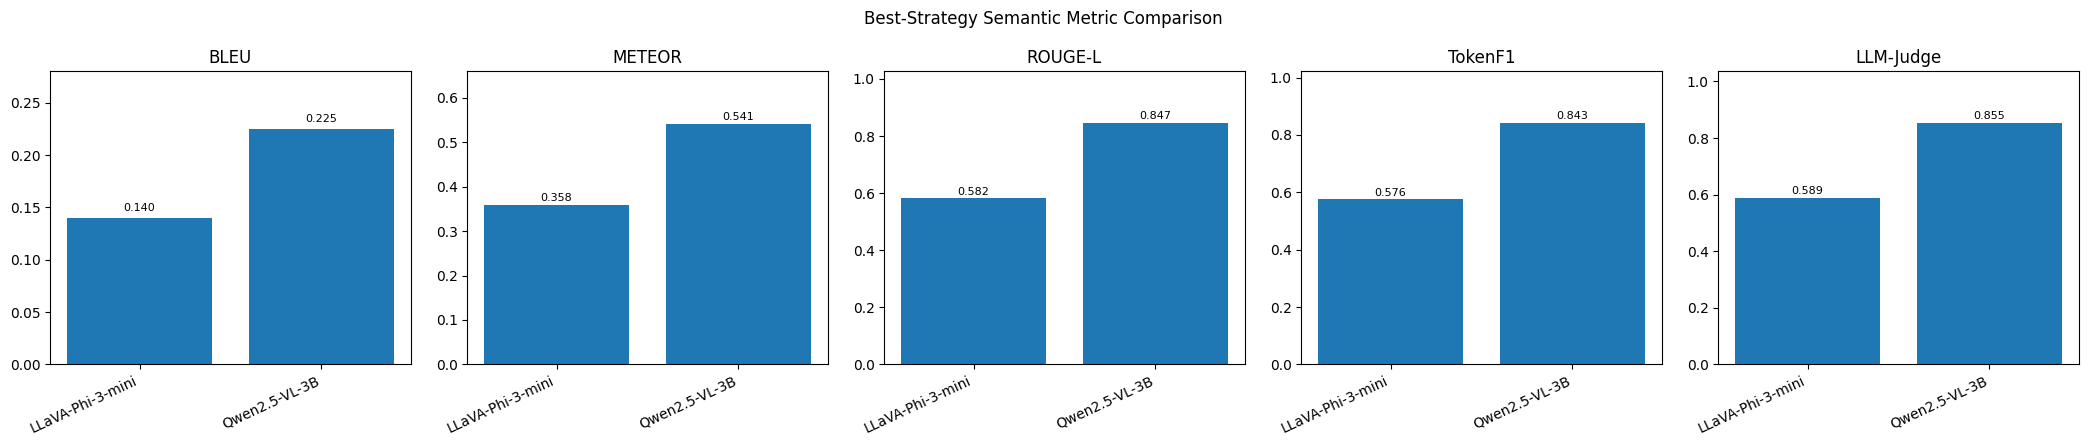

Saved: combined_report_outputs/best_strategy_semantic_metrics.png


In [55]:
# combined semantic metric figure

semantic_metrics = ["BLEU", "METEOR", "ROUGE-L", "TokenF1"]

if "LLM-Judge" in combined_summary_df.columns:
    semantic_metrics.append("LLM-Judge")

best_metric_df = best_strategy_df.copy()

fig, axes = plt.subplots(1, len(semantic_metrics), figsize=(4.2 * len(semantic_metrics), 4.5))

if len(semantic_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, semantic_metrics):
    values = best_metric_df[metric].values
    labels = best_metric_df["Model"].values

    ax.bar(labels, values)
    ax.set_title(metric)
    ax.set_ylim(0, max(values) * 1.2 + 0.01)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=25, ha="right")

    for idx, value in enumerate(values):
        ax.text(idx, value + 0.005, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Best-Strategy Semantic Metric Comparison")
plt.tight_layout()

semantic_plot_path = os.path.join(COMBINED_OUTPUT_DIR, "best_strategy_semantic_metrics.png")
plt.savefig(semantic_plot_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", semantic_plot_path)

In [56]:
# combined question-type performance

best_strategy_lookup = {
    row["ModelSlug"]: row["Strategy"]
    for _, row in best_strategy_df.iterrows()
}

best_only_parts = []

for model_slug, best_strategy in best_strategy_lookup.items():
    part = combined_df[
        (combined_df["model_slug"] == model_slug) &
        (combined_df["strategy"] == best_strategy)
    ].copy()

    best_only_parts.append(part)

best_only_df = pd.concat(best_only_parts, ignore_index=True)

category_rows = []

for (model_slug, model_name, question_type_name), group in best_only_df.groupby(["model_slug", "model", "question_type"]):
    category_rows.append({
        "Model": model_name,
        "ModelSlug": model_slug,
        "QuestionType": question_type_name,
        "NumSamples": len(group),
        "Accuracy": group["accuracy"].mean(),
        "ExactAnyMatch": group["exact_any_match"].mean(),
        "TokenF1": group["token_f1"].mean(),
        "BLEU": group["bleu"].mean(),
        "METEOR": group["meteor"].mean(),
        "ROUGE-L": group["rouge_l"].mean(),
        "LLM-Judge": group["llm_judge_similarity"].mean() if group["llm_judge_similarity"].notna().any() else np.nan,
    })

combined_category_df = pd.DataFrame(category_rows)

category_csv = os.path.join(COMBINED_OUTPUT_DIR, "combined_best_strategy_question_type_performance.csv")
category_tex = os.path.join(COMBINED_OUTPUT_DIR, "combined_best_strategy_question_type_performance.tex")

combined_category_df.to_csv(category_csv, index=False)
combined_category_df.to_latex(category_tex, index=False, float_format="%.4f")

print("Saved:", category_csv)
print("Saved:", category_tex)
display(combined_category_df.sort_values(["QuestionType", "ModelSlug"]))

Saved: combined_report_outputs/combined_best_strategy_question_type_performance.csv
Saved: combined_report_outputs/combined_best_strategy_question_type_performance.tex


,Model,ModelSlug,QuestionType,NumSamples,Accuracy,ExactAnyMatch,TokenF1,BLEU,METEOR,ROUGE-L,LLM-Judge
0,LLaVA-Phi-3-mini,llava,brand_logo,579,0.540587,0.568221,0.588830,0.122413,0.349637,0.596895,0.614853
11,Qwen2.5-VL-3B,qwen,brand_logo,579,0.820380,0.860104,0.874842,0.196489,0.515712,0.878296,0.888601
1,LLaVA-Phi-3-mini,llava,color,43,0.767442,0.790698,0.802326,0.153028,0.428348,0.802326,0.802326
12,Qwen2.5-VL-3B,qwen,color,43,0.775194,0.813953,0.837209,0.163024,0.459841,0.837209,0.813953
2,LLaVA-Phi-3-mini,llava,date_time,358,0.358473,0.371508,0.407662,0.085688,0.226876,0.408682,0.402235
13,Qwen2.5-VL-3B,qwen,date_time,358,0.639665,0.673184,0.686778,0.158142,0.404819,0.690689,0.698324
3,LLaVA-Phi-3-mini,llava,general_what,1845,0.452936,0.497561,0.581037,0.164584,0.399174,0.590099,0.604336
14,Qwen2.5-VL-3B,qwen,general_what,1845,0.760976,0.818428,0.867356,0.274163,0.615355,0.870442,0.882656
4,LLaVA-Phi-3-mini,llava,location,113,0.439528,0.504425,0.660952,0.197952,0.461340,0.653364,0.641593
15,Qwen2.5-VL-3B,qwen,location,113,0.790560,0.831858,0.875811,0.280537,0.625344,0.875650,0.871681


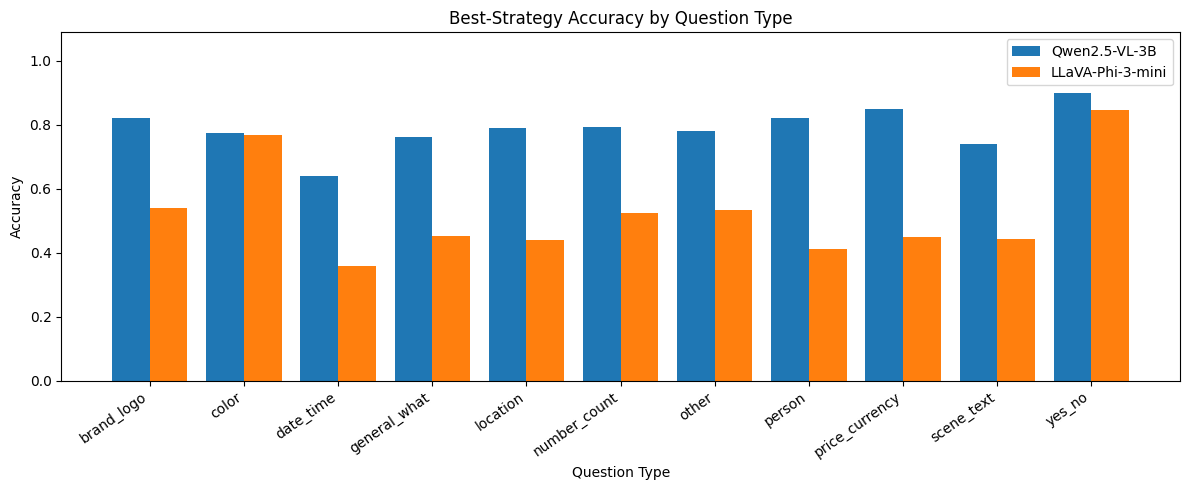

Saved: combined_report_outputs/combined_question_type_accuracy.png


In [57]:
# combined question-type accuracy figure

question_types = sorted(combined_category_df["QuestionType"].unique())
x = np.arange(len(question_types))
model_slugs = list(MODEL_CONFIGS.keys())
width = 0.8 / max(len(model_slugs), 1)

fig, ax = plt.subplots(figsize=(12, 5))

for i, model_slug in enumerate(model_slugs):
    model_plot_df = combined_category_df[combined_category_df["ModelSlug"] == model_slug].set_index("QuestionType")
    values = [model_plot_df.loc[q, "Accuracy"] if q in model_plot_df.index else np.nan for q in question_types]
    offsets = x - 0.4 + width / 2 + i * width

    ax.bar(offsets, values, width=width, label=MODEL_CONFIGS[model_slug]["display_name"])

ax.set_title("Best-Strategy Accuracy by Question Type")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Question Type")
ax.set_xticks(x)
ax.set_xticklabels(question_types, rotation=35, ha="right")
ax.set_ylim(0, max(combined_category_df["Accuracy"]) * 1.2 + 0.01)
ax.legend()

plt.tight_layout()

question_type_plot_path = os.path.join(COMBINED_OUTPUT_DIR, "combined_question_type_accuracy.png")
plt.savefig(question_type_plot_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", question_type_plot_path)

## Error breakdown

In [58]:
# combined error breakdown

error_rows = []

for (model_slug, model_name), group in best_only_df.groupby(["model_slug", "model"]):
    wrong_group = group[group["is_fully_correct"] == 0]
    total_wrong = len(wrong_group)

    for error_type_name, error_group in wrong_group.groupby("error_type"):
        error_rows.append({
            "Model": model_name,
            "ModelSlug": model_slug,
            "ErrorType": error_type_name,
            "Count": len(error_group),
            "PercentOfWrong": len(error_group) / max(total_wrong, 1),
        })

combined_error_df = pd.DataFrame(error_rows)

error_csv = os.path.join(COMBINED_OUTPUT_DIR, "combined_best_strategy_error_breakdown.csv")
error_tex = os.path.join(COMBINED_OUTPUT_DIR, "combined_best_strategy_error_breakdown.tex")

combined_error_df.to_csv(error_csv, index=False)
combined_error_df.to_latex(error_tex, index=False, float_format="%.4f")

print("Saved:", error_csv)
print("Saved:", error_tex)
display(combined_error_df.sort_values(["ModelSlug", "Count"], ascending=[True, False]))

Saved: combined_report_outputs/combined_best_strategy_error_breakdown.csv
Saved: combined_report_outputs/combined_best_strategy_error_breakdown.tex


,Model,ModelSlug,ErrorType,Count,PercentOfWrong
3,LLaVA-Phi-3-mini,llava,ocr_misread,1156,0.426254
5,LLaVA-Phi-3-mini,llava,reasoning_or_grounding_failure,575,0.212021
4,LLaVA-Phi-3-mini,llava,partial_ocr_or_partial_answer,435,0.160398
1,LLaVA-Phi-3-mini,llava,metric_mismatch,321,0.118363
2,LLaVA-Phi-3-mini,llava,number_mismatch,198,0.073009
0,LLaVA-Phi-3-mini,llava,empty_output,26,0.009587
6,LLaVA-Phi-3-mini,llava,too_verbose_or_descriptive,1,0.000369
8,Qwen2.5-VL-3B,qwen,metric_mismatch,388,0.293939
10,Qwen2.5-VL-3B,qwen,ocr_misread,359,0.271970
11,Qwen2.5-VL-3B,qwen,partial_ocr_or_partial_answer,228,0.172727


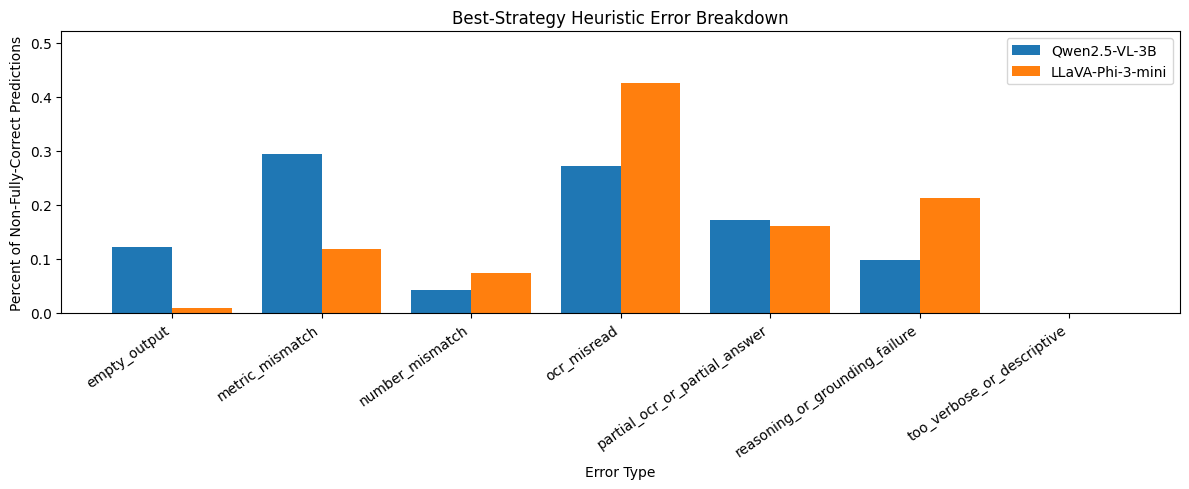

Saved: combined_report_outputs/combined_error_breakdown.png


In [59]:
# combined error breakdown figure

error_types = sorted(combined_error_df["ErrorType"].unique())
x = np.arange(len(error_types))
model_slugs = list(MODEL_CONFIGS.keys())
width = 0.8 / max(len(model_slugs), 1)

fig, ax = plt.subplots(figsize=(12, 5))

for i, model_slug in enumerate(model_slugs):
    model_plot_df = combined_error_df[combined_error_df["ModelSlug"] == model_slug].set_index("ErrorType")
    values = [model_plot_df.loc[e, "PercentOfWrong"] if e in model_plot_df.index else 0.0 for e in error_types]
    offsets = x - 0.4 + width / 2 + i * width

    ax.bar(offsets, values, width=width, label=MODEL_CONFIGS[model_slug]["display_name"])

ax.set_title("Best-Strategy Heuristic Error Breakdown")
ax.set_ylabel("Percent of Non-Fully-Correct Predictions")
ax.set_xlabel("Error Type")
ax.set_xticks(x)
ax.set_xticklabels(error_types, rotation=35, ha="right")
ax.set_ylim(0, max(combined_error_df["PercentOfWrong"]) * 1.2 + 0.01)
ax.legend()

plt.tight_layout()

error_plot_path = os.path.join(COMBINED_OUTPUT_DIR, "combined_error_breakdown.png")
plt.savefig(error_plot_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", error_plot_path)

Saved: combined_report_outputs/best_strategy_overlap_counts.csv
Saved: combined_report_outputs/best_strategy_overlap_counts.tex
Saved: combined_report_outputs/best_strategy_per_sample_comparison.csv


,OutcomeGroup,Count,Percent
0,both_correct,2023,0.4046
1,qwen_only_correct,1657,0.3314
2,both_wrong,1055,0.2110
3,llava_only_correct,265,0.0530


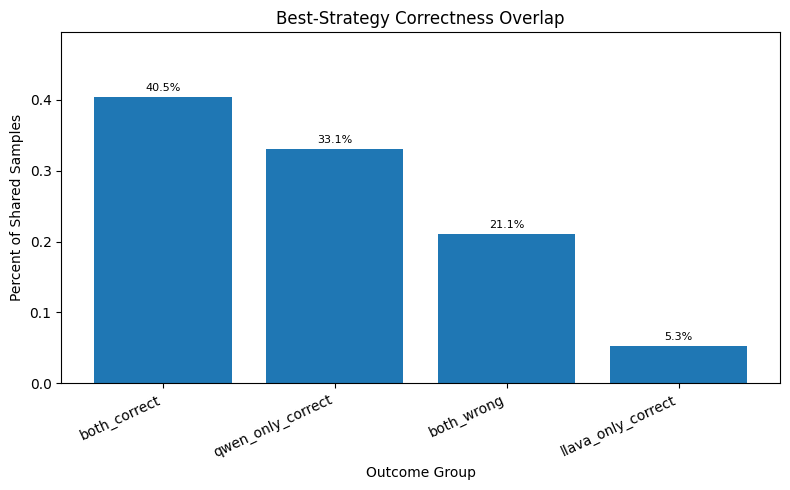

Saved: combined_report_outputs/best_strategy_correctness_overlap.png


In [60]:
# overlap analysis between best strategies

if len(best_strategy_lookup) == 2:
    model_a, model_b = list(best_strategy_lookup.keys())

    a_strategy = best_strategy_lookup[model_a]
    b_strategy = best_strategy_lookup[model_b]

    a_df = combined_df[
        (combined_df["model_slug"] == model_a) &
        (combined_df["strategy"] == a_strategy)
    ].copy()

    b_df = combined_df[
        (combined_df["model_slug"] == model_b) &
        (combined_df["strategy"] == b_strategy)
    ].copy()

    comparison_df = a_df.merge(
        b_df,
        on="sample_idx",
        suffixes=(f"_{model_a}", f"_{model_b}")
    )

    comparison_df["outcome_group"] = np.select(
        [
            (comparison_df[f"is_fully_correct_{model_a}"] == 1) & (comparison_df[f"is_fully_correct_{model_b}"] == 1),
            (comparison_df[f"is_fully_correct_{model_a}"] == 1) & (comparison_df[f"is_fully_correct_{model_b}"] == 0),
            (comparison_df[f"is_fully_correct_{model_a}"] == 0) & (comparison_df[f"is_fully_correct_{model_b}"] == 1),
            (comparison_df[f"is_fully_correct_{model_a}"] == 0) & (comparison_df[f"is_fully_correct_{model_b}"] == 0),
        ],
        [
            "both_correct",
            f"{model_a}_only_correct",
            f"{model_b}_only_correct",
            "both_wrong",
        ],
        default="other"
    )

    overlap_counts_df = comparison_df["outcome_group"].value_counts().reset_index()
    overlap_counts_df.columns = ["OutcomeGroup", "Count"]
    overlap_counts_df["Percent"] = overlap_counts_df["Count"] / len(comparison_df)

    overlap_counts_csv = os.path.join(COMBINED_OUTPUT_DIR, "best_strategy_overlap_counts.csv")
    overlap_counts_tex = os.path.join(COMBINED_OUTPUT_DIR, "best_strategy_overlap_counts.tex")
    comparison_csv = os.path.join(COMBINED_OUTPUT_DIR, "best_strategy_per_sample_comparison.csv")

    overlap_counts_df.to_csv(overlap_counts_csv, index=False)
    overlap_counts_df.to_latex(overlap_counts_tex, index=False, float_format="%.4f")
    comparison_df.to_csv(comparison_csv, index=False)

    print("Saved:", overlap_counts_csv)
    print("Saved:", overlap_counts_tex)
    print("Saved:", comparison_csv)

    display(overlap_counts_df)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(overlap_counts_df["OutcomeGroup"], overlap_counts_df["Percent"])
    ax.set_title("Best-Strategy Correctness Overlap")
    ax.set_ylabel("Percent of Shared Samples")
    ax.set_xlabel("Outcome Group")
    ax.set_ylim(0, max(overlap_counts_df["Percent"]) * 1.2 + 0.01)
    ax.set_xticks(range(len(overlap_counts_df["OutcomeGroup"])))
    ax.set_xticklabels(overlap_counts_df["OutcomeGroup"], rotation=25, ha="right")

    for idx, value in enumerate(overlap_counts_df["Percent"]):
        ax.text(idx, value + 0.005, f"{value:.1%}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()

    overlap_plot_path = os.path.join(COMBINED_OUTPUT_DIR, "best_strategy_correctness_overlap.png")
    plt.savefig(overlap_plot_path, dpi=180, bbox_inches="tight")
    plt.show()

    print("Saved:", overlap_plot_path)

## Manual error analysis

In [61]:
# manual error review sample across both models

manual_review_parts = []

for model_slug, best_strategy in best_strategy_lookup.items():
    part = combined_df[
        (combined_df["model_slug"] == model_slug) &
        (combined_df["strategy"] == best_strategy) &
        (combined_df["is_fully_correct"] == 0)
    ].copy()

    part = part.sample(n=min(60, len(part)), random_state=261)
    manual_review_parts.append(part)

manual_review_df = pd.concat(manual_review_parts, ignore_index=True)

manual_review_columns = [
    "model",
    "model_slug",
    "strategy",
    "sample_idx",
    "question",
    "answers",
    "prediction",
    "raw_prediction",
    "accuracy",
    "llm_judge_similarity",
    "error_type",
    "question_type",
    "answer_type",
]

manual_review_df = manual_review_df[[c for c in manual_review_columns if c in manual_review_df.columns]]
manual_review_df["manual_error_label"] = ""
manual_review_df["manual_notes"] = ""

manual_review_csv = os.path.join(COMBINED_OUTPUT_DIR, "manual_error_review_template_combined.csv")
manual_review_df.to_csv(manual_review_csv, index=False)

print("Saved:", manual_review_csv)
display(manual_review_df.head(20))

Saved: combined_report_outputs/manual_error_review_template_combined.csv


,model,model_slug,strategy,sample_idx,question,answers,prediction,raw_prediction,accuracy,llm_judge_similarity,error_type,question_type,answer_type,manual_error_label,manual_notes
0,LLaVA-Phi-3-mini,llava,baseline,4866,what time is it?,"[4:55, 9:55, unanswerable, priorities, 4:55, u...",1:20,1:20,0.000000,0.0,number_mismatch,date_time,numeric,,
1,LLaVA-Phi-3-mini,llava,baseline,4206,what business once occupied this store?,"[woolworths, woolworths, woolworths, woolworth...",cushman & wakefield,Cushman & Wakefield,0.000000,0.0,ocr_misread,general_what,single_word,,
2,LLaVA-Phi-3-mini,llava,baseline,461,what is the menu telling you to press?,"[start, start, start, press start, start, star...",p,P,0.000000,0.0,reasoning_or_grounding_failure,general_what,single_word,,
3,LLaVA-Phi-3-mini,llava,baseline,4675,what does it say on the shirt of the man holdi...,"[c4, it says c$, c4, c4, c4, c4, c4, c4, c4, c4]",scooter,Scooter,0.000000,0.0,ocr_misread,scene_text,alphanumeric,,
4,LLaVA-Phi-3-mini,llava,baseline,2166,where are the new york municipal airports loca...,"[north beach, floyd bennett field and north be...",city of new york,City of New York,0.333333,1.0,metric_mismatch,location,multi_word,,
5,LLaVA-Phi-3-mini,llava,baseline,3201,what time is shown?,"[3:07, 3:06, 3:07, 9:05, 3:06, 3:07, 3:06, 3:0...",1:20,1:20,0.000000,0.0,ocr_misread,date_time,numeric,,
6,LLaVA-Phi-3-mini,llava,baseline,4716,how many book on the shelf?,[answering does not require reading text in th...,9,9,0.000000,0.0,number_mismatch,number_count,numeric,,
7,LLaVA-Phi-3-mini,llava,baseline,980,what is the number of the player in the middle?,"[3, 35, 33, 3, 3, 33, 3, 3, 3, 33]",20,20,0.000000,0.0,number_mismatch,number_count,numeric,,
8,LLaVA-Phi-3-mini,llava,baseline,4768,how many pence is this?,"[six, 6, six, six, six, six, six, six, six, six]",6,6,0.333333,1.0,metric_mismatch,number_count,numeric,,
9,LLaVA-Phi-3-mini,llava,baseline,3878,what time is it on the clock?,"[2:52, 2:52, 3:52 , 3:53, 2:53, 2:52, 3:52, 2:...",1:00,1:00,0.000000,0.0,number_mismatch,date_time,numeric,,


## Qualitative Examples

In [63]:
dataset = load_dataset("lmms-lab/textvqa")
eval_data = dataset["validation"]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/20 [00:00<?, ?it/s]

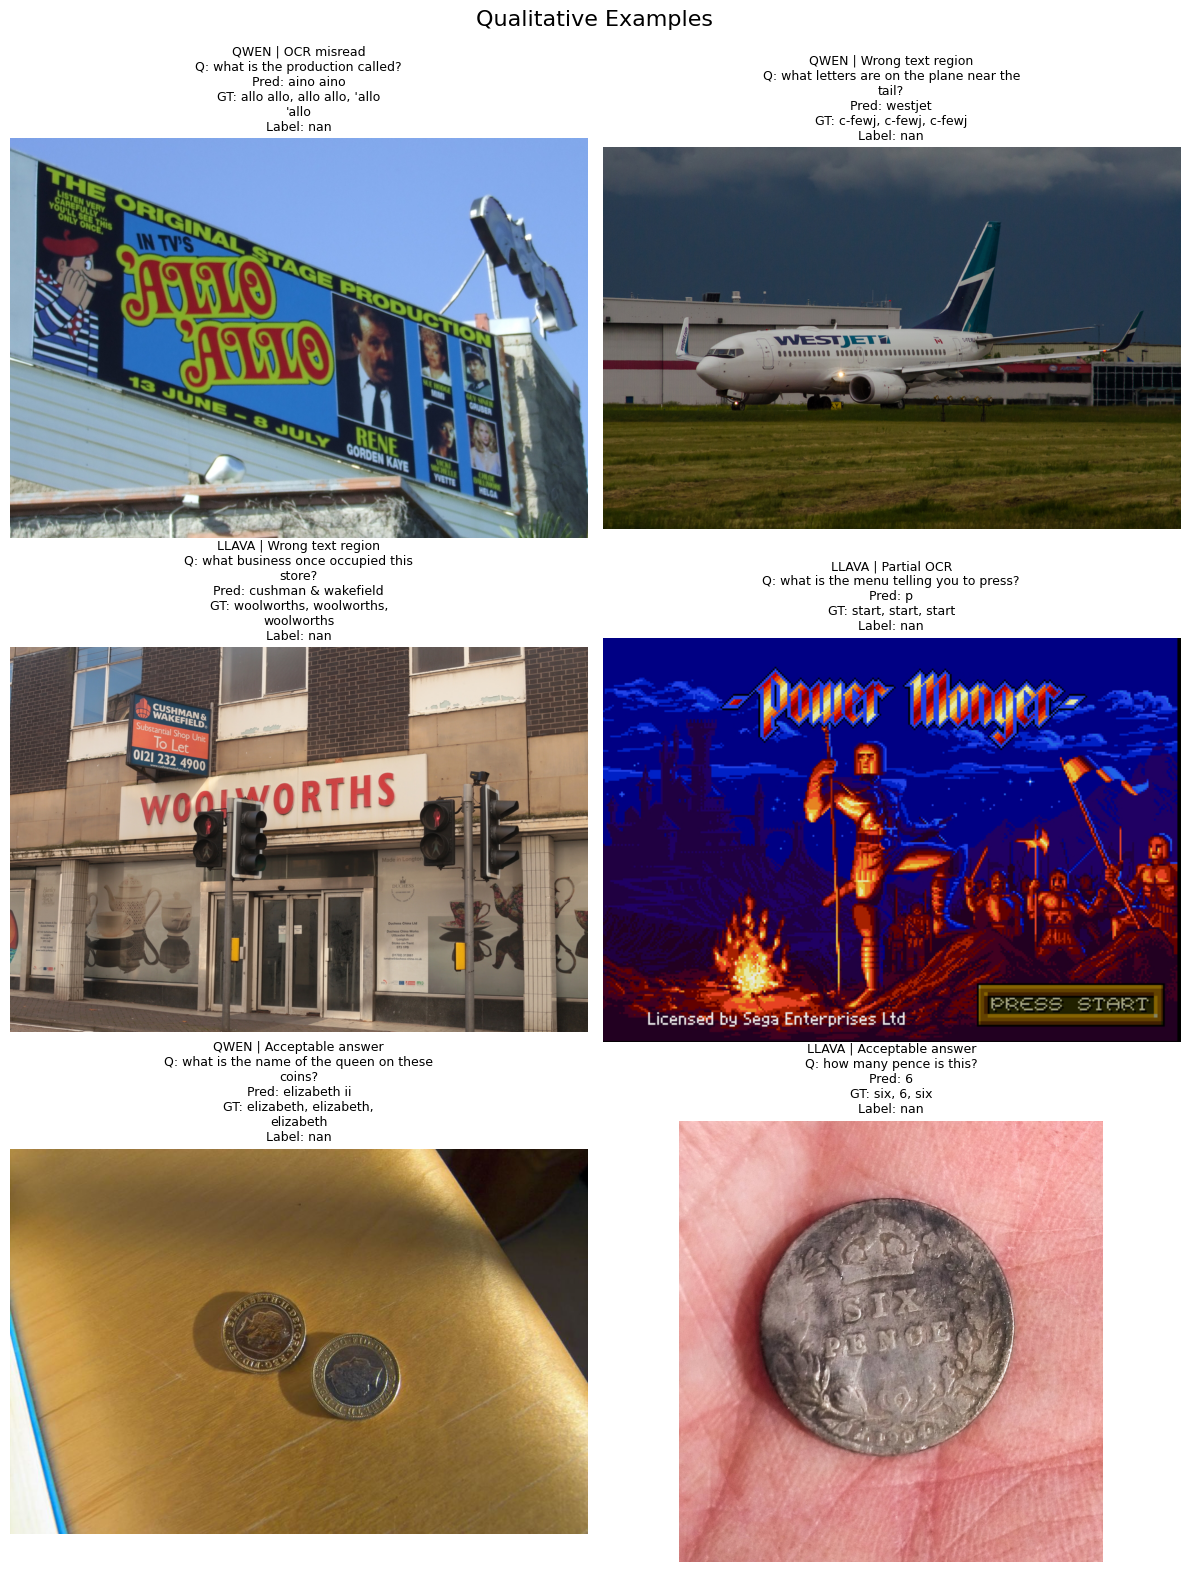

In [66]:
review_df = pd.read_csv("combined_report_outputs/manual_error_review_template_combined.csv")

examples = [
    ("qwen", 4576, "OCR misread"),
    ("qwen", 3191, "Wrong text region"),
    ("llava", 4206, "Wrong text region"),
    ("llava", 461, "Partial OCR"),
    ("qwen", 1593, "Acceptable answer"),
    ("llava", 4768, "Acceptable answer"),
]

def parse_answers(x):
    try:
        x = ast.literal_eval(x) if isinstance(x, str) else x
    except Exception:
        return str(x)
    return ", ".join(map(str, x[:3])) if isinstance(x, list) else str(x)

def get_row(model_slug, sample_idx):
    rows = review_df[
        (review_df["model_slug"] == model_slug) &
        (review_df["sample_idx"] == sample_idx)
    ]
    if len(rows) == 0:
        raise ValueError(f"missing example: {model_slug}, {sample_idx}")
    return rows.iloc[0]

rows = [get_row(m, s) for m, s, _ in examples]
tags = [t for _, _, t in examples]

fig, axes = plt.subplots(3, 2, figsize=(12, 16))
axes = axes.flatten()

for ax, row, tag in zip(axes, rows, tags):
    image = eval_data[int(row["sample_idx"])]["image"]

    title = (
        f"{row['model_slug'].upper()} | {tag}\n"
        f"Q: {textwrap.fill(str(row['question']), 38)}\n"
        f"Pred: {textwrap.fill(str(row['prediction']), 24)}\n"
        f"GT: {textwrap.fill(parse_answers(row['answers']), 28)}\n"
        f"Label: {row['manual_error_label']}"
    )

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(title, fontsize=9)

plt.suptitle("Qualitative Examples", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
semantic_plot_path = os.path.join(COMBINED_OUTPUT_DIR, "qualitative_examples_grid.png")
plt.savefig(semantic_plot_path, dpi=180, bbox_inches="tight")
plt.show()

## Final output inventory

In [68]:
print("=" * 80)
print("Combined analysis complete")
print("=" * 80)
print("Output folder:", COMBINED_OUTPUT_DIR)
print()
print("Main files for report:")
print(summary_csv)
print(summary_tex)
print(best_csv)
print(best_tex)
print(improvement_csv)
print(improvement_tex)
print(accuracy_plot_path)
print(semantic_plot_path)
print(category_csv)
print(category_tex)
print(question_type_plot_path)
print(error_csv)
print(error_tex)
print(error_plot_path)
print(manual_review_csv)

Combined analysis complete
Output folder: combined_report_outputs

Main files for report:
combined_report_outputs/combined_strategy_summary.csv
combined_report_outputs/combined_strategy_summary.tex
combined_report_outputs/best_strategy_by_model.csv
combined_report_outputs/best_strategy_by_model.tex
combined_report_outputs/combined_prompt_improvements.csv
combined_report_outputs/combined_prompt_improvements.tex
combined_report_outputs/combined_accuracy_by_strategy.png
combined_report_outputs/qualitative_examples_grid.png
combined_report_outputs/combined_best_strategy_question_type_performance.csv
combined_report_outputs/combined_best_strategy_question_type_performance.tex
combined_report_outputs/combined_question_type_accuracy.png
combined_report_outputs/combined_best_strategy_error_breakdown.csv
combined_report_outputs/combined_best_strategy_error_breakdown.tex
combined_report_outputs/combined_error_breakdown.png
combined_report_outputs/manual_error_review_template_combined.csv
